# Mall Customer Clustering with K-Means Clustering


- **CustomerID:** Ini adalah identifikasi unik untuk setiap pelanggan. Digunakan untuk mengidentifikasi dan membedakan antara satu pelanggan dengan pelanggan lainnya.

- **Genre:** Merupakan jenis kelamin atau jenis kelamin pelanggan, yang dapat berupa 'Male' (Laki-laki) atau 'Female' (Perempuan).

- **Age:** Ini adalah kolom yang berisi informasi tentang usia pelanggan. Biasanya diukur dalam tahun dan memberikan informasi tentang seberapa muda atau tua pelanggan tersebut.

- **Annual Income:** Menunjukkan pendapatan tahunan pelanggan dalam ribu dolar (k$). Informasi ini membantu untuk memahami seberapa besar keuangan pelanggan dan dapat berpengaruh pada perilaku belanja mereka.

- **Spending Score (1-100):** Merupakan skor atau penilaian yang menggambarkan seberapa sering atau seberapa banyak pelanggan tersebut menghabiskan uang dalam skala 1 hingga 100. Nilai yang lebih tinggi mungkin menunjukkan perilaku belanja yang lebih aktif atau besar.

# Persiapan Data

In [ ]:
import pandas as pd           # Untuk mengolah data dalam bentuk tabel (DataFrame)
import matplotlib.pyplot as plt # Untuk membuat grafik dan visualisasi dasar
import seaborn as sns          # Untuk membuat tampilan grafik menjadi lebih menarik dan modern
from sklearn.cluster import KMeans # Algoritma AI untuk mengelompokkan data secara otomatis (Clustering)
import sqlite3                 # Untuk menghubungkan Python dengan database SQL (SQLite)

# Menampilkan pesan bahwa library telah siap
print("Library untuk Analisis Cluster dan Database telah siap!")


Library untuk Analisis Cluster dan Database telah siap!


# Data Ingestion

In [ ]:
# Dataset ini berisi: ID, Gender, Usia, Pendapatan Tahunan, dan Skor Pengeluaran
df = pd.read_csv('https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2025%20-%20Hierarchical%20Clustering/Mall_Customers.csv')

# Sederhanakan nama kolom agar tidak ada spasi atau simbol (penting untuk format SQL)
df.columns = ['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']

# Mulai menyusun script SQL
table_name = "customers"

# Header: Perintah pembuatan tabel
sql_script = f"DROP TABLE IF EXISTS {table_name};\n"
sql_script += f"""CREATE TABLE {table_name} (
    CustomerID INTEGER,
    Gender TEXT,
    Age INTEGER,
    Annual_Income REAL,
    Spending_Score INTEGER
);\n\n"""

# Body: Perintah masukkan data (INSERT INTO)
print("Sedang menyusun script SQL...")
insert_commands = []
for _, row in df.iterrows():
    command = f"INSERT INTO {table_name} (CustomerID, Gender, Age, Annual_Income, Spending_Score) " \
              f"VALUES ({int(row['CustomerID'])}, '{row['Gender']}', {int(row['Age'])}, {row['Annual_Income']}, {int(row['Spending_Score'])});"
    insert_commands.append(command)

# Gabungkan semua perintah insert
sql_script += "\n".join(insert_commands)

# 4. Simpan ke file .sql
with open("mall_customers.sql", "w") as f:
    f.write(sql_script)

print("✅ File 'mall_customers.sql' berhasil dibuat!")



Sedang menyusun script SQL...
✅ File 'mall_customers.sql' berhasil dibuat!


# Load Database

In [ ]:
# Membuat database SQLite
conn = sqlite3.connect("mall_customers.db")
cursor = conn.cursor()

# Membaca file sql
with open("/content/mall_customers.sql", "r") as f:
    sql_script = f.read()

# Tampilkan hasilnya
cursor.executescript(sql_script)
conn.commit()

df = pd.read_sql("SELECT * FROM customers", conn)
df

,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15.0,39
1,2,Male,21,15.0,81
2,3,Female,20,16.0,6
3,4,Female,23,16.0,77
4,5,Female,31,17.0,40
...,...,...,...,...,...
195,196,Female,35,120.0,79
196,197,Female,45,126.0,28
197,198,Male,32,126.0,74
198,199,Male,32,137.0,18


In [ ]:
# Menggunakan nama yang deskriptif
dimensi_data = df.shape

print(f'Jumlah Baris : {dimensi_data[0]}')
print(f'Jumlah Kolom : {dimensi_data[1]}')
print('\n')
df.info()


Jumlah Baris : 200
Jumlah Kolom : 5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CustomerID      200 non-null    int64  
 1   Gender          200 non-null    object 
 2   Age             200 non-null    int64  
 3   Annual_Income   200 non-null    float64
 4   Spending_Score  200 non-null    int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 7.9+ KB




---
## Prepocessing Data



In [ ]:
# Mengecek jumlah data yang kosong (Missing Values) pada setiap kolom
jumlah_data_kosong = df.isna().sum()
print("Jumlah data kosong per kolom:")
print(jumlah_data_kosong)

# Mengecek jumlah baris data yang sama persis (Duplikat)
jumlah_duplikat = df.duplicated().sum()
print(f"\nTotal data duplikat: {jumlah_duplikat}")



Jumlah data kosong per kolom:
CustomerID        0
Gender            0
Age               0
Annual_Income     0
Spending_Score    0
dtype: int64

Total data duplikat: 0


# Modeling

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

# 1. Menentukan Fitur (X)
# Menghapus kolom 'Gender' (dan biasanya CustomerID) agar fokus pada data numerik saja
data_fitur = df.drop(['CustomerID','Gender'], axis=1)

# 2. Standarisasi Data (Scaling)
# Menggunakan MinMaxScaler agar semua nilai berada di rentang 0-1
# Ini penting supaya kolom berangka besar (Pendapatan) tidak mendominasi kolom berangka kecil (Usia)
skala_minimal_maksimal = MinMaxScaler()
data_terskala = skala_minimal_maksimal.fit_transform(data_fitur)

# 3. Mencari Jumlah Cluster Terbaik (Metode Elbow)
# Inersia mengukur seberapa jauh jarak poin data ke pusat kelompoknya
daftar_inersia = []

for i in range(1, 11):
    # n_init=10 digunakan untuk memastikan hasil yang stabil dan menghindari peringatan sistem
    model_kmeans = KMeans(n_clusters=i, n_init=10, random_state=42)
    model_kmeans.fit(data_terskala)

    # Memasukkan nilai inersia ke dalam list
    daftar_inersia.append(model_kmeans.inertia_)

print("✅ Proses penghitungan inersia untuk metode Elbow selesai.")


✅ Proses penghitungan inersia untuk metode Elbow selesai.


In [ ]:
data_fitur

,Age,Annual_Income,Spending_Score
0,19,15.0,39
1,21,15.0,81
2,20,16.0,6
3,23,16.0,77
4,31,17.0,40
...,...,...,...
195,35,120.0,79
196,45,126.0,28
197,32,126.0,74
198,32,137.0,18


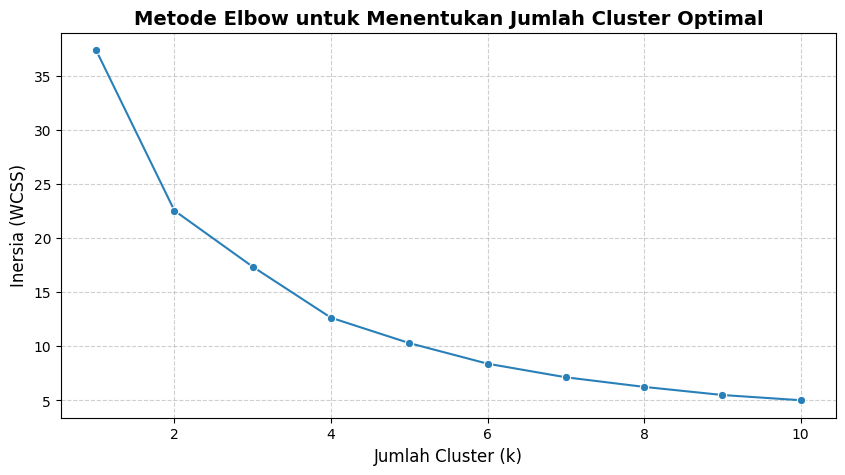

In [ ]:
# 1. Menyiapkan bingkai grafik
fig, ax = plt.subplots(figsize=(10, 5))

# 2. Membuat grafik garis untuk inersia
# Menambahkan marker='o' agar titik setiap cluster terlihat jelas
sns.lineplot(x=list(range(1, 11)), y=daftar_inersia, ax=ax, marker='o', color='#2980b9')

# 3. Memberikan label dan judul yang lebih informatif
ax.set_title('Metode Elbow untuk Menentukan Jumlah Cluster Optimal', fontsize=14, fontweight='bold')
ax.set_xlabel('Jumlah Cluster (k)', fontsize=12)
ax.set_ylabel('Inersia (WCSS)', fontsize=12)

# 4. Menambahkan grid agar titik pertemuan lebih mudah dibaca
ax.grid(True, linestyle='--', alpha=0.6)

plt.show()


**"Data pelanggan ini sebaiknya dibagi menjadi berapa kelompok?"**


* Sumbu X (Jumlah Cluster): Menunjukkan berapa banyak kelompok yang ingin kita buat (1 sampai 10).
* Sumbu Y (Inersia): Angka ini menunjukkan seberapa "berantakan" atau seberapa jauh jarak data pelanggan ke pusat kelompoknya. Semakin kecil angkanya, semakin rapat kelompoknya.
* Arti Garis Tersebut: Kita mencari titik di mana penurunan inersia mulai melandai (seperti bentuk sikut manusia).
* Dari angka 1 ke 2, inersia turun tajam (bagus).
   * Dari angka 2 ke 4, masih turun lumayan.
   * Setelah angka 4 atau 5, grafik mulai mendatar (landai).

**Kesimpulannya:**

Titik "sikut" pada grafik kamu berada di sekitar angka 4 atau 5. Artinya, membagi pelanggan mal tersebut menjadi 4 atau 5 kelompok adalah jumlah yang paling ideal secara statistik.

Jika kita pilih terlalu banyak (misal 10), kelompoknya jadi terlalu kecil dan susah dianalisis. Jika terlalu sedikit (misal 2), kelompoknya terlalu umum.


In [ ]:
# 1. Menentukan jumlah kelompok berdasarkan hasil Elbow (misal: 5 cluster)
jumlah_cluster = 5

# 2. Inisialisasi model dengan parameter yang konsisten
model_kmeans_final = KMeans(n_clusters=jumlah_cluster, n_init=10, random_state=42)

# 3. Melatih model dan memberikan label pada data yang sudah terskala (data_terskala)
label_kelompok = model_kmeans_final.fit_predict(data_terskala)

# 4. Mengambil koordinat titik pusat kelompok (centroids)
titik_pusat = model_kmeans_final.cluster_centers_

# 5. Memasukkan hasil label kelompok ke dalam tabel asli
df['Grup_Pelanggan'] = label_kelompok

# 6. Menampilkan hasil akhir
print(f"✅ Model KMeans dengan {jumlah_cluster} cluster berhasil diterapkan.")
print("-" * 30)
display(df.head())


✅ Model KMeans dengan 5 cluster berhasil diterapkan.
------------------------------


,CustomerID,Gender,Age,Annual_Income,Spending_Score,Grup_Pelanggan
0,1,Male,19,15.0,39,1
1,2,Male,21,15.0,81,2
2,3,Female,20,16.0,6,1
3,4,Female,23,16.0,77,2
4,5,Female,31,17.0,40,1


In [ ]:
# 1. Menampilkan koordinat titik pusat (dalam skala 0-1 karena tadi pakai MinMaxScaler)
print("Titik Pusat (Skala 0-1):")
print(titik_pusat)

# 2. Mengembalikan nilai titik pusat ke skala aslinya agar bisa dibaca (Misal: Rupiah, Tahun)
titik_pusat_asli = skala_minimal_maksimal.inverse_transform(titik_pusat)

# 3. Menampilkan dalam bentuk tabel agar lebih rapi
df_pusat = pd.DataFrame(titik_pusat_asli, columns=data_fitur.columns)
df_pusat.index.name = 'Cluster'
print("\nKarakteristik Rata-rata Setiap Kelompok (Nilai Asli):")
display(df_pusat)


Titik Pusat (Skala 0-1):
[[0.28605769 0.58278689 0.82168367]
 [0.17425432 0.30311141 0.40857976]
 [0.14464883 0.09265859 0.79148181]
 [0.5        0.61584699 0.17278912]
 [0.72214854 0.27444884 0.41608023]]

Karakteristik Rata-rata Setiap Kelompok (Nilai Asli):


,Age,Annual_Income,Spending_Score
Cluster,,,
0,32.875000,86.100000,81.525000
1,27.061224,51.979592,41.040816
2,25.521739,26.304348,78.565217
3,44.000000,90.133333,17.933333
4,55.551724,48.482759,41.775862


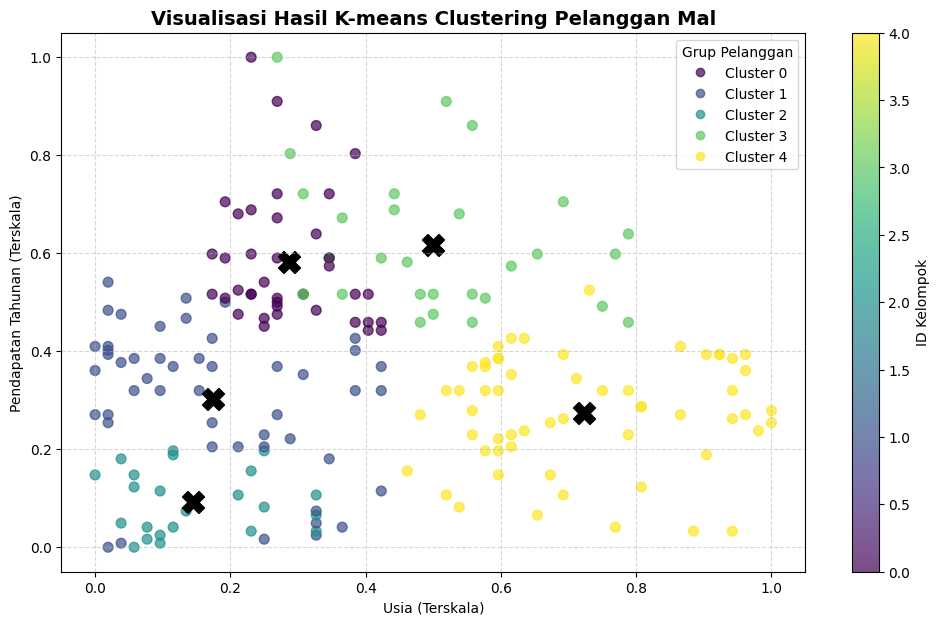

In [ ]:
import matplotlib.pyplot as plt

# 1. Menyiapkan bingkai grafik
plt.figure(figsize=(12, 7))

# 2. Membuat Scatter Plot untuk setiap titik data pelanggan
# data_terskala[:, 0] adalah kolom Usia, data_terskala[:, 1] adalah kolom Pendapatan
scatter = plt.scatter(data_terskala[:, 0], data_terskala[:, 1],
                      c=label_kelompok, s=50, cmap='viridis', alpha=0.7)

# 3. Menambahkan Titik Pusat (Centroids) ke dalam grafik
# Titik hitam transparan berukuran besar (s=200) sebagai penanda pusat kelompok
plt.scatter(titik_pusat[:, 0], titik_pusat[:, 1],
            c='black', s=250, marker='X', label='Pusat Cluster')

# 4. Menambahkan Legenda untuk memudahkan pembacaan
plt.legend(handles=scatter.legend_elements()[0],
           labels=['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4'],
           title="Grup Pelanggan")

# 5. Memberikan Label pada Sumbu (Sesuaikan dengan data fiturnmu)
plt.xlabel('Usia (Terskala)')
plt.ylabel('Pendapatan Tahunan (Terskala)')
plt.title('Visualisasi Hasil K-means Clustering Pelanggan Mal', fontsize=14, fontweight='bold')

# 6. Menambahkan Colorbar sebagai indikator warna
plt.colorbar(scatter, label='ID Kelompok')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [ ]:
# 1. Menghitung jumlah anggota di setiap cluster
# Pastikan nama kolom sesuai (Grup_Pelanggan atau Cluster_ID)
jumlah_per_kelompok = df['Grup_Pelanggan'].value_counts().sort_index()

print("Jumlah Pelanggan per Kelompok:")
print(jumlah_per_kelompok)

# 2. Opsional: Menampilkan dalam bentuk persentase agar lebih mudah dianalisis
print("\nPersentase per Kelompok (%):")
print((df['Grup_Pelanggan'].value_counts(normalize=True) * 100).round(2))


Jumlah Pelanggan per Kelompok:
Grup_Pelanggan
0    40
1    49
2    23
3    30
4    58
Name: count, dtype: int64

Persentase per Kelompok (%):
Grup_Pelanggan
4    29.0
1    24.5
0    20.0
3    15.0
2    11.5
Name: proportion, dtype: float64


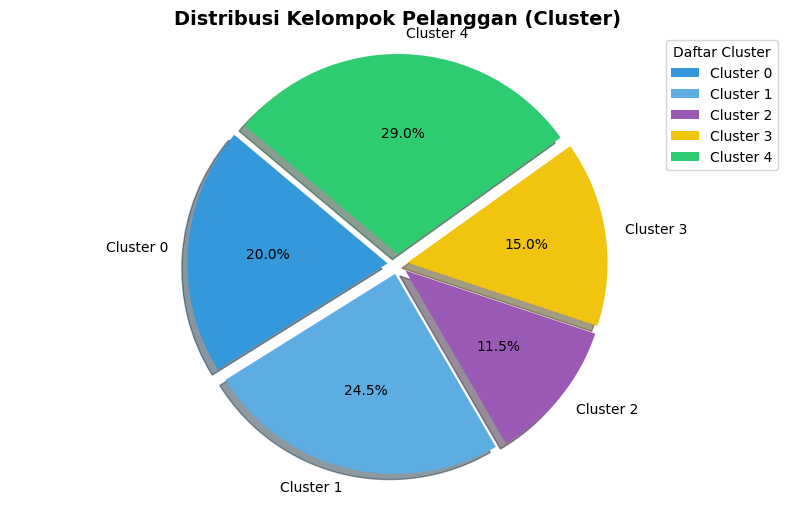

In [ ]:
import matplotlib.pyplot as plt

# 1. Menyiapkan data untuk grafik (menggunakan hasil hitungan sebelumnya)
# Kita gunakan .sort_index() agar urutan Cluster 0 sampai 4 rapi
data_pie = df['Grup_Pelanggan'].value_counts().sort_index()

sizes = data_pie.values
# Nama label kita buat lebih informatif, misal: Cluster 0, Cluster 1, dst.
labels = [f'Cluster {i}' for i in data_pie.index]

# 2. Pengaturan warna yang lebih modern dan kontras
colors = ['#3498db', '#5dade2', '#9b59b6', '#f1c40f', '#2ecc71']

# 3. Membuat Pie Chart
plt.figure(figsize=(10, 6))
# explode memberikan sedikit jarak pada potongan pie agar terlihat lebih elegan
explode = (0.05, 0.05, 0.05, 0.05, 0.05)

plt.pie(sizes,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%',
        startangle=140,
        explode=explode,
        shadow=True)

# 4. Menampilkan judul dan legenda
plt.title('Distribusi Kelompok Pelanggan (Cluster)', fontsize=14, fontweight='bold')
plt.legend(labels, loc="upper right", title="Daftar Cluster")

plt.axis('equal') # Memastikan bentuk lingkaran sempurna
plt.show()


# Aplikasi

In [ ]:
import numpy as np

# 1. Masukkan data baru secara manual
# Format: [Usia, Pendapatan_Tahunan, Skor_Pengeluaran]
data_baru = [[25, 50, 75]]

# 2. WAJIB: Lakukan Penskalaan (Scaling)
# Kita gunakan objek 'skala_minimal_maksimal' yang sudah kita buat sebelumnya
data_baru_terskala = skala_minimal_maksimal.transform(data_baru)

# 3. Prediksi Cluster
# Menggunakan model 'model_kmeans_final' yang sudah dilatih
prediksi_cluster = model_kmeans_final.predict(data_baru_terskala)

# 4. Tampilkan Hasil
print(f"--- Hasil Analisis Pelanggan Baru ---")
print(f"Data Input (Usia, Gaji, Skor): {data_baru[0]}")
print(f"Pelanggan tersebut masuk ke: Cluster {prediksi_cluster[0]}")

# 5. Penjelasan Karakteristik (Opsional)
# Kamu bisa melihat rata-rata di cluster tersebut untuk memberi saran bisnis
print(f"\nTip: Pelanggan ini memiliki perilaku yang mirip dengan kelompok Cluster {prediksi_cluster[0]}")


--- Hasil Analisis Pelanggan Baru ---
Data Input (Usia, Gaji, Skor): [25, 50, 75]
Pelanggan tersebut masuk ke: Cluster 2

Tip: Pelanggan ini memiliki perilaku yang mirip dengan kelompok Cluster 2


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [ ]:
print("--- SISTEM PREDIKSI KATEGORI PELANGGAN ---")

# 1. Mengambil input dari keyboard
# Kita gunakan float() agar bisa menerima angka desimal jika diperlukan
try:
    usia = float(input("Masukkan Usia pelanggan: "))
    pendapatan = float(input("Masukkan Pendapatan Tahunan (k$): "))
    skor_belanja = float(input("Masukkan Skor Pengeluaran (1-100): "))

    # 2. Menyusun data ke dalam format yang sesuai (2D Array)
    data_input = [[usia, pendapatan, skor_belanja]]

    # 3. WAJIB: Transformasi data menggunakan scaler yang sudah ada
    # Ini supaya angka yang kamu ketik diubah ke skala 0-1
    data_terskala_baru = skala_minimal_maksimal.transform(data_input)

    # 4. Melakukan Prediksi Cluster
    hasil_cluster = model_kmeans_final.predict(data_terskala_baru)[0]

    # 5. Menampilkan Hasil
    print("\n" + "="*40)
    print(f"HASIL ANALISIS:")
    print(f"Pelanggan tersebut dikategorikan ke dalam: CLUSTER {hasil_cluster}")
    print("="*40)



except ValueError:
    print("\n❌ Input salah! Pastikan kamu hanya memasukkan angka.")
except Exception as e:
    print(f"\n❌ Terjadi kesalahan: {e}")


--- SISTEM PREDIKSI KATEGORI PELANGGAN ---
Masukkan Usia pelanggan: 60
Masukkan Pendapatan Tahunan (k$): 200
Masukkan Skor Pengeluaran (1-100): 9

HASIL ANALISIS:
Pelanggan tersebut dikategorikan ke dalam: CLUSTER 3


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
